<a href="https://colab.research.google.com/github/RamyAkin/AI-Models/blob/main/CNNMNISTTrial1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(X_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

X_train = X_train.reshape(-1, 28, 28,1).astype("float32") / 255.0
X_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
history = model.fit(X_train, y_train, epochs=15, validation_data=(x_test, y_test))

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9059 - loss: 0.3172 - val_accuracy: 0.9857 - val_loss: 7.0991
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9858 - loss: 0.0459 - val_accuracy: 0.9863 - val_loss: 8.4300
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9911 - loss: 0.0300 - val_accuracy: 0.9849 - val_loss: 8.3828
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9926 - loss: 0.0234 - val_accuracy: 0.9850 - val_loss: 8.9705
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9953 - loss: 0.0159 - val_accuracy: 0.9874 - val_loss: 10.1186
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9962 - loss: 0.0124 - val_accuracy: 0.9877 - val_loss: 10.3199
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9969 - loss: 0.0097 - val_accuracy: 0.9767 - val_loss: 20.1544
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9970 - loss: 0.007

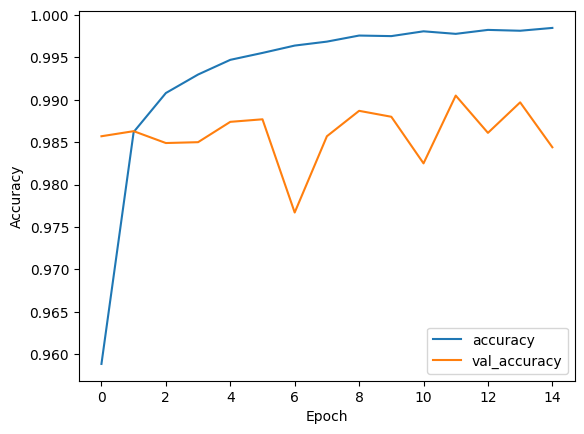

In [5]:
plt.plot(history.history['accuracy'], label= 'accuracy')
plt.plot(history.history['val_accuracy'], label= 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


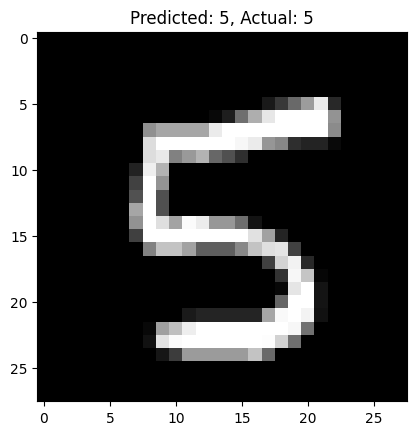

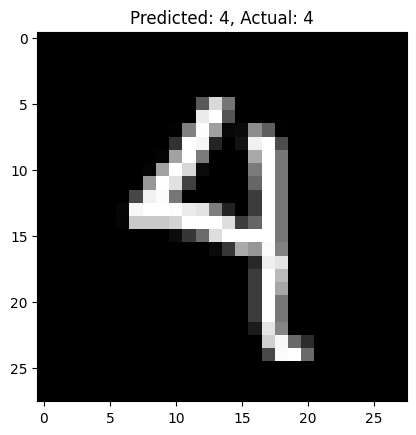

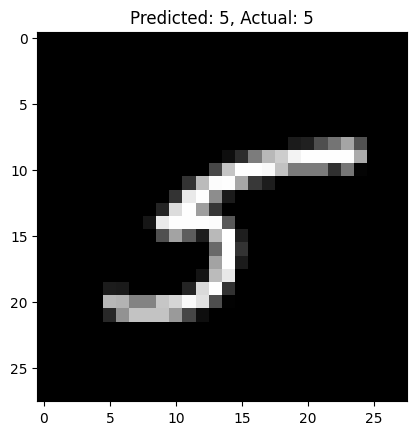

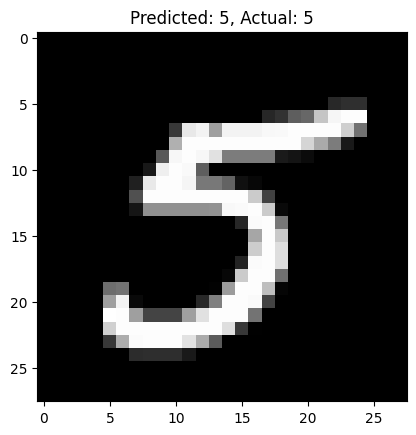

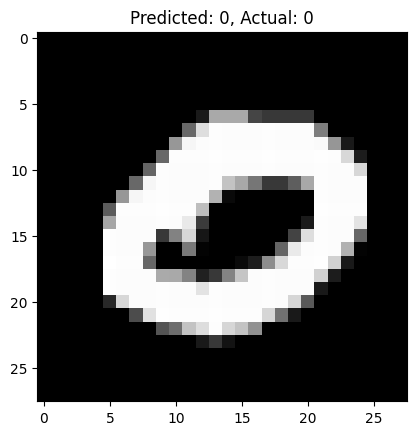

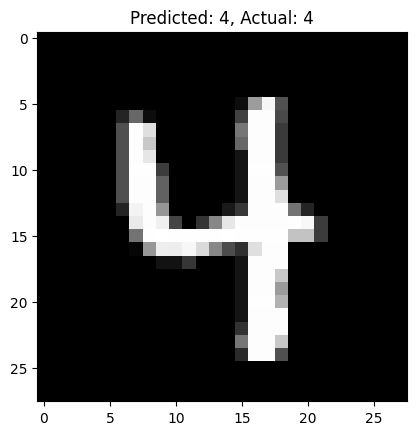

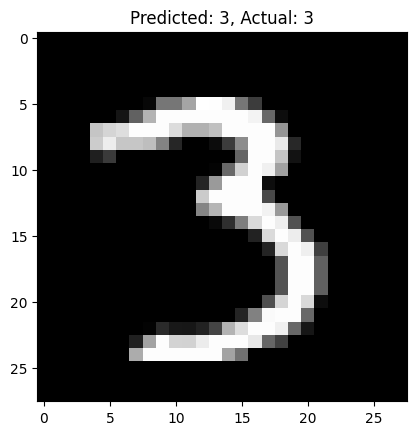

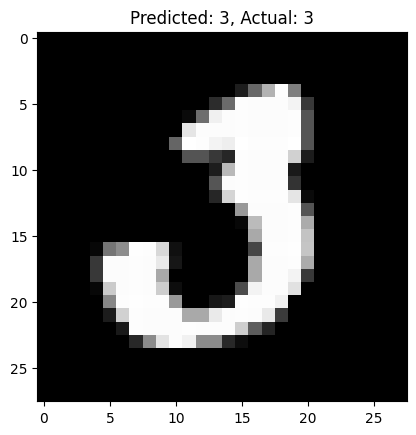

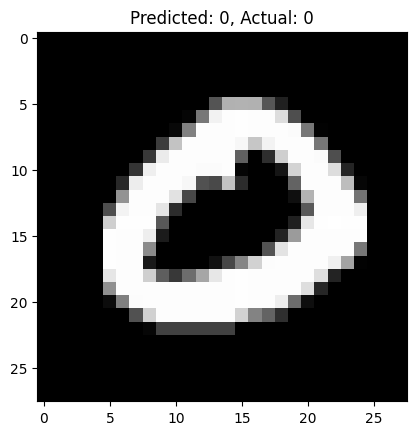

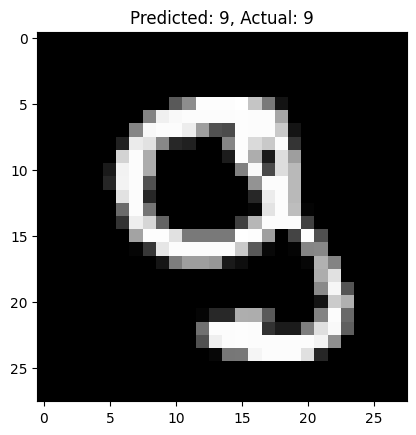

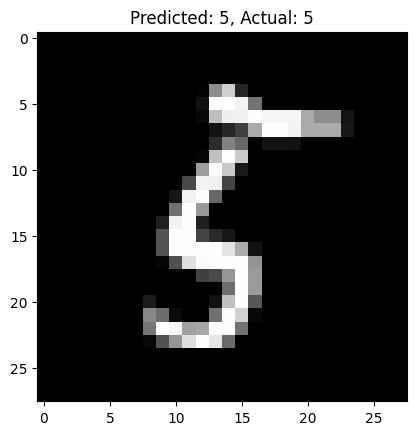

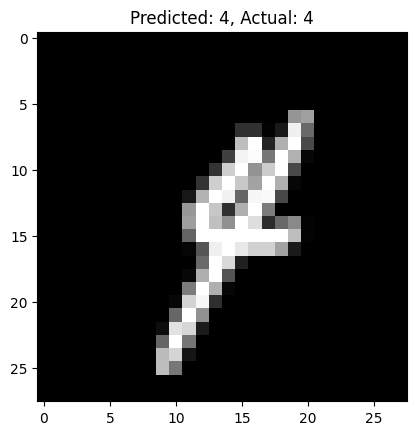

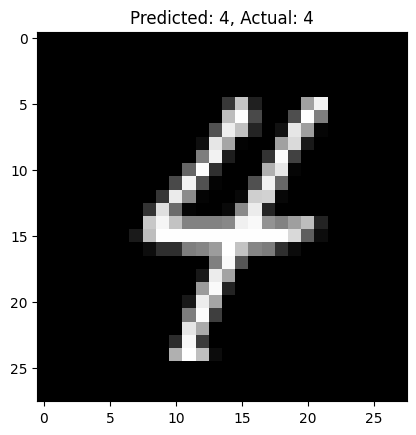

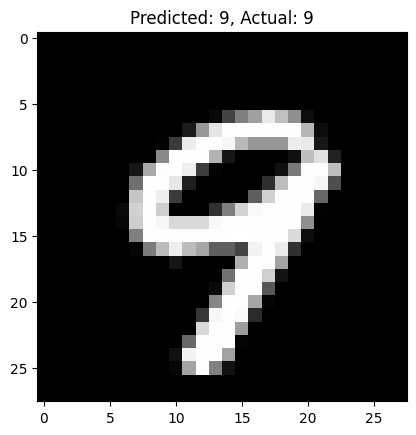

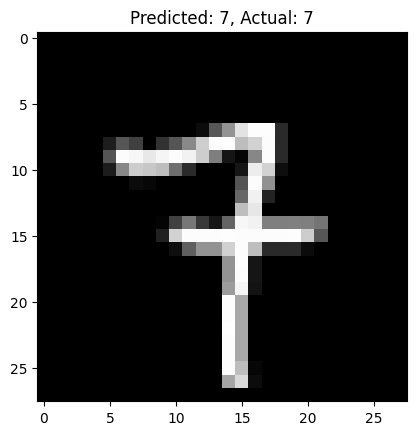

In [6]:
import random
prediction = model.predict(x_test)
classified_indices = [i for i in range(len(y_test))]
random_samples = random.sample(classified_indices, 15)
for i in random_samples:
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Predicted: {np.argmax(prediction[i])}, Actual: {y_test[i]}")
    plt.show()


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step


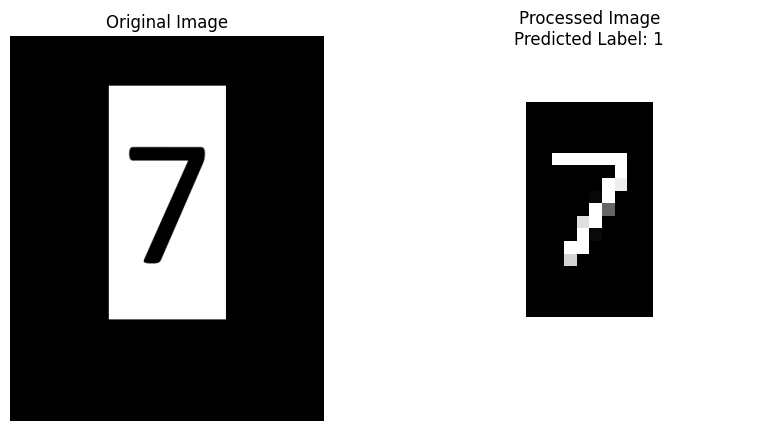

In [10]:
from matplotlib import image
import cv2

image_path = "/content/drive/MyDrive/UniWork3rdYear/test_Images_MNIST/234.png"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error, Image not loaded, check file path")
else:
  #Displaying Original and Processed Image
  plt.figure(figsize=(10, 5))

  #Original Image
  plt.subplot(1, 2, 1)
  plt.imshow(image, cmap='gray')
  plt.title('Original Image')
  plt.axis('off')

  #Resize image to match mnist dimensions
  resized_image = cv2.resize(image, (28, 28))

  #Invert colours if needed
  resized_image = 255 - resized_image

  #Normalize and reshape the Image
  image_resized = resized_image.astype("float32") / 255.0
  image_resized = image_resized.reshape(-1, 28, 28, 1)

  prediction = model.predict(image_resized)
  predicted_label = np.argmax(prediction)

  #Processed Image
  plt.subplot(1, 2, 2)
  plt.imshow(resized_image.squeeze(), cmap='gray')
  plt.title(f'Processed Image\nPredicted Label: {predicted_label}')
  plt.axis('off')

  plt.show()

